In [2]:
!pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 3.9 MB/s eta 0:00:00a 0:00:01


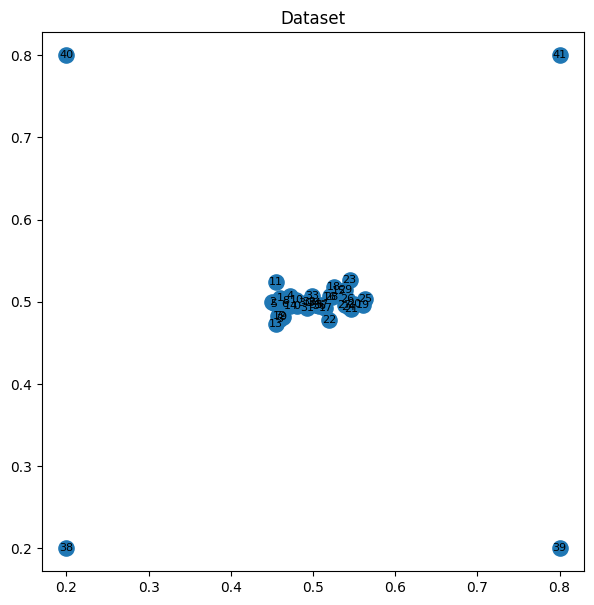

In [115]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

def make_good_demo_dataset():
    """
    Returns points as: [id, x, y]
    One dense cluster split by a vertical boundary + bridge points + noise.
    """
    pts = []

    # Left dense blob (cluster part A)
    left = np.random.normal(loc=[0.46, 0.50], scale=[0.012, 0.012], size=(15, 2))

    # Right dense blob (cluster part B)
    right = np.random.normal(loc=[0.54, 0.50], scale=[0.012, 0.012], size=(15, 2))

    # Bridge points near boundary (these are critical for ghost + merging)
    bridge_x = np.linspace(0.49, 0.51, 8)
    bridge_y = 0.50 + np.random.normal(0, 0.004, size=8)
    bridge = np.column_stack([bridge_x, bridge_y])

    # Noise points far away
    noise = np.array([
        [0.20, 0.20],
        [0.80, 0.20],
        [0.20, 0.80],
        [0.80, 0.80],
    ])

    all_xy = np.vstack([left, right, bridge, noise])

    for i, (x, y) in enumerate(all_xy):
        pts.append([i, x, y])

    return np.array(pts, dtype=float)

points = make_good_demo_dataset()

plt.figure(figsize=(7,7))
plt.scatter(points[:,1], points[:,2], s=120)
for p in points:
    plt.text(p[1], p[2], str(int(p[0])), ha="center", va="center", fontsize=8)
plt.title("Dataset")
plt.axis("equal")
plt.show()


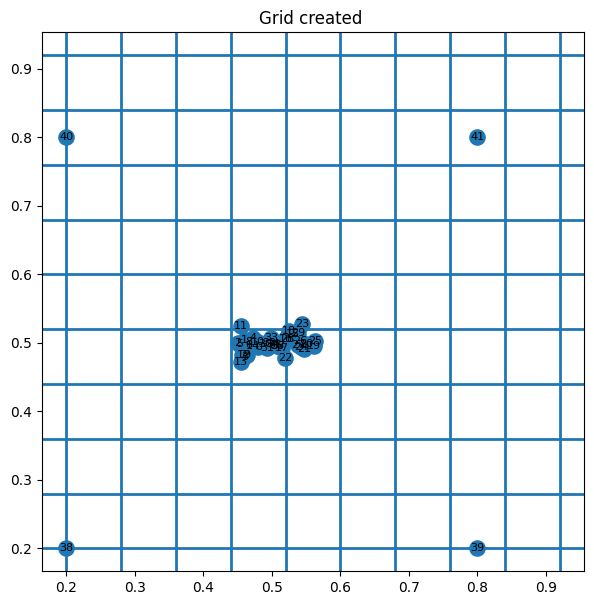

In [116]:
import numpy as np
import matplotlib.pyplot as plt
import math

# cell size same idea as PartitionConfiguration
cell_size = 0.08

min_x = points[:,1].min()
max_x = points[:,1].max()
min_y = points[:,2].min()
max_y = points[:,2].max()

# number of cells EXACTLY like Java
num_cells_x = int(math.ceil((max_x - min_x) / cell_size)) + 1
num_cells_y = int(math.ceil((max_y - min_y) / cell_size)) + 1

plt.figure(figsize=(7,7))

# vertical grid lines
for i in range(num_cells_x + 1):
    x = min_x + i * cell_size
    plt.axvline(x, linewidth=2)

# horizontal grid lines
for j in range(num_cells_y + 1):
    y = min_y + j * cell_size
    plt.axhline(y, linewidth=2)

# plot points
plt.scatter(points[:,1], points[:,2], s=120)

# annotate
for p in points:
    plt.text(p[1], p[2], str(int(p[0])), fontsize=8,
             ha='center', va='center')

plt.title("Grid created ")
plt.axis("equal")
plt.show()


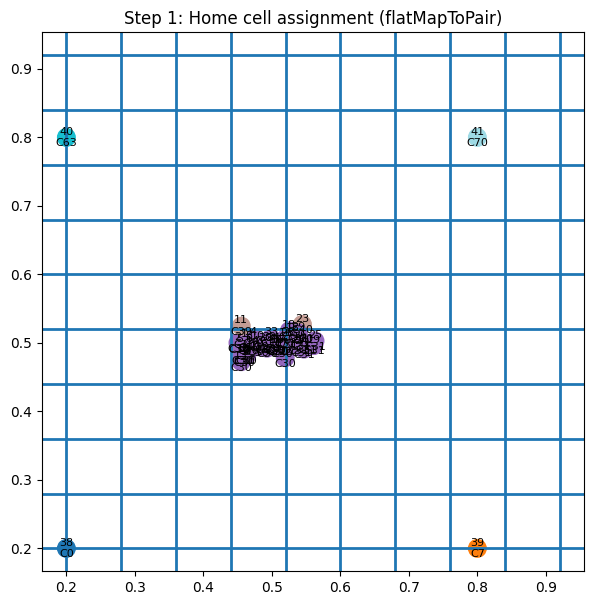

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import math

plt.figure(figsize=(7,7))

# draw grid
for i in range(num_cells_x + 1):
    plt.axvline(min_x + i * cell_size, linewidth=2)
for j in range(num_cells_y + 1):
    plt.axhline(min_y + j * cell_size, linewidth=2)

# compute home cell for each point
cell_colors = []
cell_ids = []

for p in points:
    homeX = int(math.floor((p[1] - min_x) / cell_size))
    homeY = int(math.floor((p[2] - min_y) / cell_size))
    cellId = homeY * num_cells_x + homeX

    cell_colors.append(cellId)
    cell_ids.append(cellId)

# plot
plt.scatter(points[:,1], points[:,2],
            c=cell_colors, s=160, cmap="tab20")

# annotate
for i, p in enumerate(points):
    plt.text(p[1], p[2], f"{int(p[0])}\nC{cell_ids[i]}",
             ha="center", va="center", fontsize=8)

plt.title("Step 1: Home cell assignment (flatMapToPair)")
plt.axis("equal")
plt.show()


# Ghost Point Replication

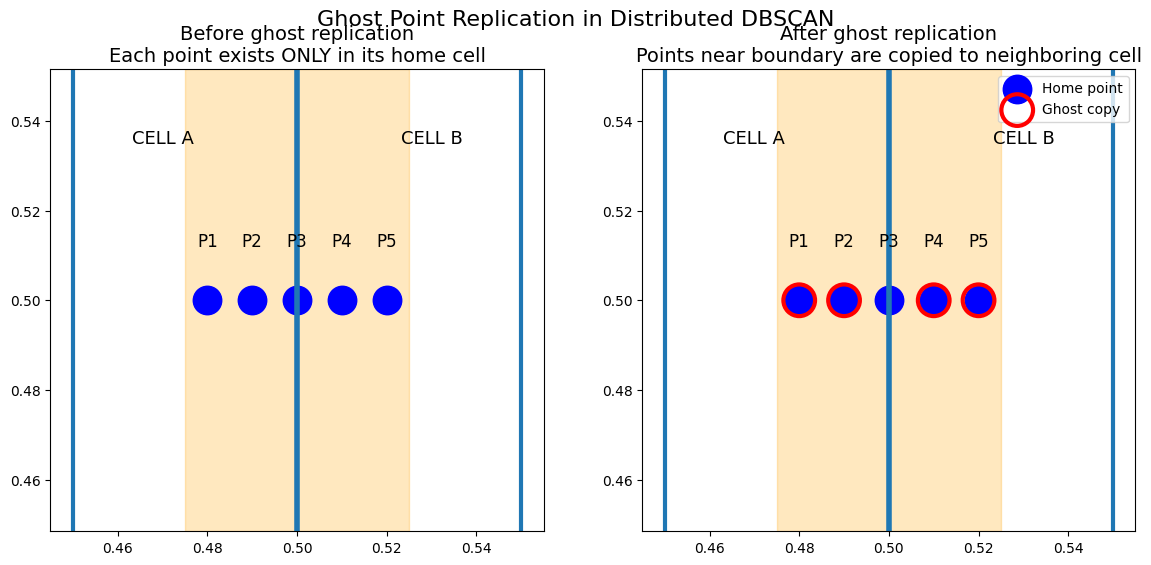

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Simple dataset crossing two cells
# -------------------------------------------------
points = np.array([
    [1, 0.48, 0.50],
    [2, 0.49, 0.50],
    [3, 0.50, 0.50],
    [4, 0.51, 0.50],
    [5, 0.52, 0.50],
])

boundary = 0.50
buffer = 0.025

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# =================================================
# BEFORE REPLICATION
# =================================================
ax = axes[0]

ax.axvline(0.45, linewidth=3)
ax.axvline(0.55, linewidth=3)
ax.axvline(boundary, linewidth=4)

ax.text(0.47, 0.535, "CELL A", fontsize=13, ha="center")
ax.text(0.53, 0.535, "CELL B", fontsize=13, ha="center")

# buffer
ax.axvspan(boundary-buffer, boundary, color="orange", alpha=0.25)
ax.axvspan(boundary, boundary+buffer, color="orange", alpha=0.25)

ax.scatter(points[:,1], points[:,2],
           s=420, color="blue")

for p in points:
    ax.text(p[1], p[2]+0.012, f"P{int(p[0])}", ha="center", fontsize=12)

ax.set_title("Before ghost replication\nEach point exists ONLY in its home cell",
             fontsize=14)

ax.axis("equal")

# =================================================
# AFTER REPLICATION
# =================================================
ax = axes[1]

ax.axvline(0.45, linewidth=3)
ax.axvline(0.55, linewidth=3)
ax.axvline(boundary, linewidth=4)

ax.text(0.47, 0.535, "CELL A", fontsize=13, ha="center")
ax.text(0.53, 0.535, "CELL B", fontsize=13, ha="center")

ax.axvspan(boundary-buffer, boundary, color="orange", alpha=0.25)
ax.axvspan(boundary, boundary+buffer, color="orange", alpha=0.25)

# home points
ax.scatter(points[:,1], points[:,2],
           s=420, color="blue", label="Home point")

# ghost copies
left = points[points[:,1] < boundary]
right = points[points[:,1] > boundary]

ax.scatter(left[:,1], left[:,2],
           s=520, facecolors='none', edgecolors='red',
           linewidth=3, label="Ghost copy")

ax.scatter(right[:,1], right[:,2],
           s=520, facecolors='none', edgecolors='red',
           linewidth=3)

for p in points:
    ax.text(p[1], p[2]+0.012, f"P{int(p[0])}", ha="center", fontsize=12)

ax.set_title(
    "After ghost replication\n"
    "Points near boundary are copied to neighboring cell",
    fontsize=14
)

ax.legend()
ax.axis("equal")

plt.suptitle(
    "Ghost Point Replication in Distributed DBSCAN",
    fontsize=16
)

plt.show()


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


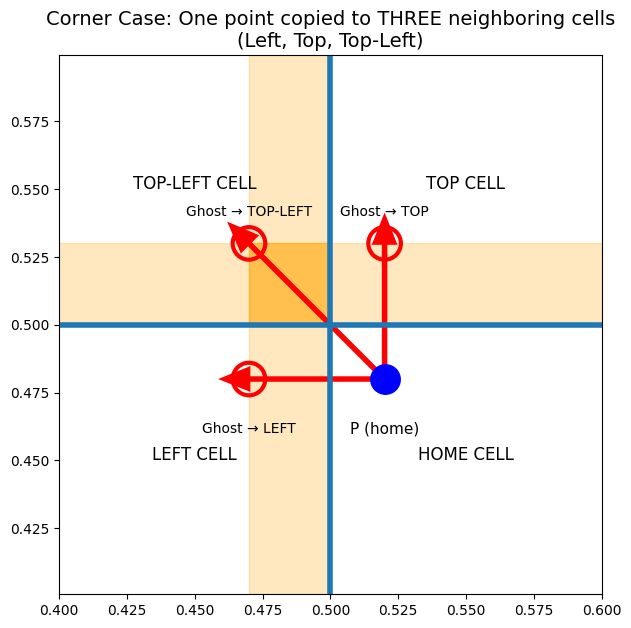

In [99]:
import matplotlib.pyplot as plt

# ----------------------------------------
# Parameters
# ----------------------------------------
boundary_x = 0.50
boundary_y = 0.50
buffer = 0.03

# Point near TOP-LEFT corner of HOME cell
px, py = 0.52, 0.48

plt.figure(figsize=(7,7))

# ----------------------------------------
# Cell boundaries
# ----------------------------------------
plt.axvline(boundary_x, linewidth=4)
plt.axhline(boundary_y, linewidth=4)

# ----------------------------------------
# Buffer regions
# ----------------------------------------
# left buffer
plt.axvspan(boundary_x-buffer, boundary_x, color="orange", alpha=0.25)

# top buffer
plt.axhspan(boundary_y, boundary_y+buffer, color="orange", alpha=0.25)

# overlap region (corner)
plt.fill_between(
    [boundary_x-buffer, boundary_x],
    boundary_y,
    boundary_y+buffer,
    color="orange",
    alpha=0.45
)

# ----------------------------------------
# Cell labels
# ----------------------------------------
plt.text(0.45, 0.55, "TOP-LEFT CELL", fontsize=12, ha="center")
plt.text(0.55, 0.55, "TOP CELL", fontsize=12, ha="center")
plt.text(0.45, 0.45, "LEFT CELL", fontsize=12, ha="center")
plt.text(0.55, 0.45, "HOME CELL", fontsize=12, ha="center")

# ----------------------------------------
# HOME POINT
# ----------------------------------------
plt.scatter(px, py, s=450, color="blue", zorder=6)
plt.text(px, py-0.02, "P (home)", ha="center", fontsize=11)

# ----------------------------------------
# Ghost copy positions
# ----------------------------------------
ghost_left     = (px - 0.05, py)
ghost_top      = (px, py + 0.05)
ghost_topleft  = (px - 0.05, py + 0.05)

# Draw ghost points
for gx, gy in [ghost_left, ghost_top, ghost_topleft]:
    plt.scatter(
        gx, gy,
        s=550,
        facecolors="none",
        edgecolors="red",
        linewidth=3,
        zorder=7
    )

# ----------------------------------------
# Arrows (replication directions)
# ----------------------------------------
plt.arrow(px, py, -0.05,  0.00, head_width=0.008, head_length=0.01, color="red", linewidth=2)
plt.arrow(px, py,  0.00,  0.05, head_width=0.008, head_length=0.01, color="red", linewidth=2)
plt.arrow(px, py, -0.05,  0.05, head_width=0.008, head_length=0.01, color="red", linewidth=2)

# ----------------------------------------
# Labels
# ----------------------------------------
plt.text(ghost_left[0], ghost_left[1]-0.02, "Ghost → LEFT", ha="center")
plt.text(ghost_top[0], ghost_top[1]+0.01, "Ghost → TOP", ha="center")
plt.text(ghost_topleft[0], ghost_topleft[1]+0.01, "Ghost → TOP-LEFT", ha="center")

# ----------------------------------------
# Final formatting
# ----------------------------------------
plt.title(
    "Corner Case: One point copied to THREE neighboring cells\n"
    "(Left, Top, Top-Left)",
    fontsize=14
)

plt.axis("equal")
plt.xlim(0.40, 0.60)
plt.ylim(0.40, 0.60)
plt.show()


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


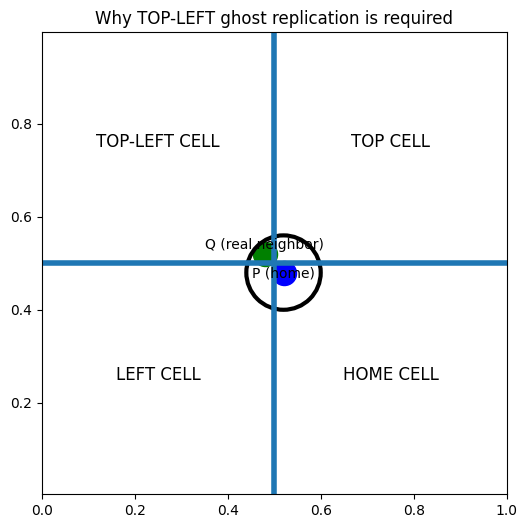

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

# draw grid
plt.axvline(0.5, linewidth=4)
plt.axhline(0.5, linewidth=4)

plt.text(0.25, 0.75, "TOP-LEFT CELL", fontsize=12, ha="center")
plt.text(0.75, 0.75, "TOP CELL", fontsize=12, ha="center")
plt.text(0.25, 0.25, "LEFT CELL", fontsize=12, ha="center")
plt.text(0.75, 0.25, "HOME CELL", fontsize=12, ha="center")

# query point near corner
plt.scatter(0.52, 0.48, s=300, color="blue")
plt.text(0.52, 0.47, "P (home)", ha="center")

# neighbor in diagonal
plt.scatter(0.48, 0.52, s=300, color="green")
plt.text(0.48, 0.53, "Q (real neighbor)", ha="center")

# epsilon circle
circle = plt.Circle((0.52, 0.48), 0.08, fill=False, linewidth=3)
plt.gca().add_patch(circle)

plt.title("Why TOP-LEFT ghost replication is required")
plt.axis("equal")
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()


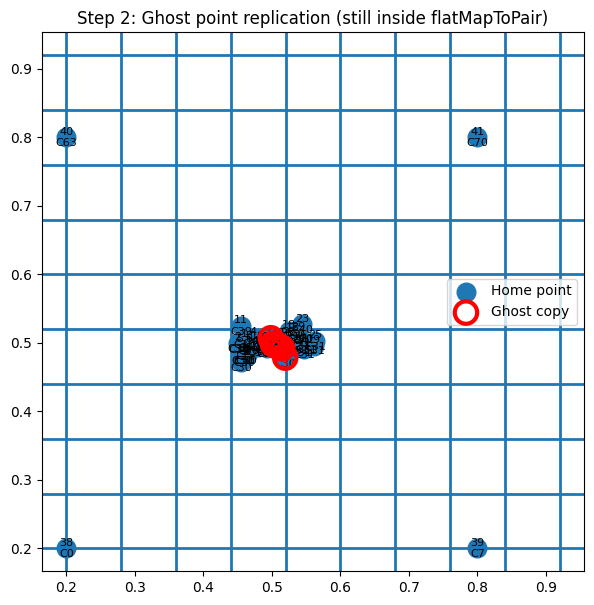

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import math

plt.figure(figsize=(7,7))

# redraw grid
for i in range(num_cells_x + 1):
    plt.axvline(min_x + i * cell_size, linewidth=2)
for j in range(num_cells_y + 1):
    plt.axhline(min_y + j * cell_size, linewidth=2)

buffer = cell_size * 0.3  # visual buffer (matches eps idea)

home_pts = []
ghost_pts = []

home_labels = []
ghost_labels = []

for i, p in enumerate(points):
    x, y = p[1], p[2]

    homeX = int(math.floor((x - min_x) / cell_size))
    homeY = int(math.floor((y - min_y) / cell_size))
    homeCell = homeY * num_cells_x + homeX

    cellMinX = min_x + homeX * cell_size
    cellMaxX = cellMinX + cell_size

    # always add home
    home_pts.append(p)
    home_labels.append(f"{int(p[0])}\nC{homeCell}")

    # check right boundary → ghost
    if cellMaxX - x <= buffer and homeX < num_cells_x - 1:
        ghostX = homeX + 1
        ghostCell = homeY * num_cells_x + ghostX
        ghost_pts.append(p)
        ghost_labels.append(f"{int(p[0])}\nC{ghostCell}")

home_pts = np.array(home_pts)
ghost_pts = np.array(ghost_pts)

# plot home points
plt.scatter(
    home_pts[:,1], home_pts[:,2],
    s=180, label="Home point", zorder=3
)

# plot ghost points
if len(ghost_pts) > 0:
    plt.scatter(
        ghost_pts[:,1], ghost_pts[:,2],
        s=260, facecolors='none', edgecolors='red',
        linewidth=3, label="Ghost copy", zorder=4
    )

# annotate
for i, p in enumerate(home_pts):
    plt.text(p[1], p[2], home_labels[i],
             ha='center', va='center', fontsize=8)

for i, p in enumerate(ghost_pts):
    plt.text(p[1], p[2], ghost_labels[i],
             ha='center', va='center', fontsize=8, color='red')

plt.title("Step 2: Ghost point replication (still inside flatMapToPair)")
plt.legend()
plt.axis("equal")
plt.show()


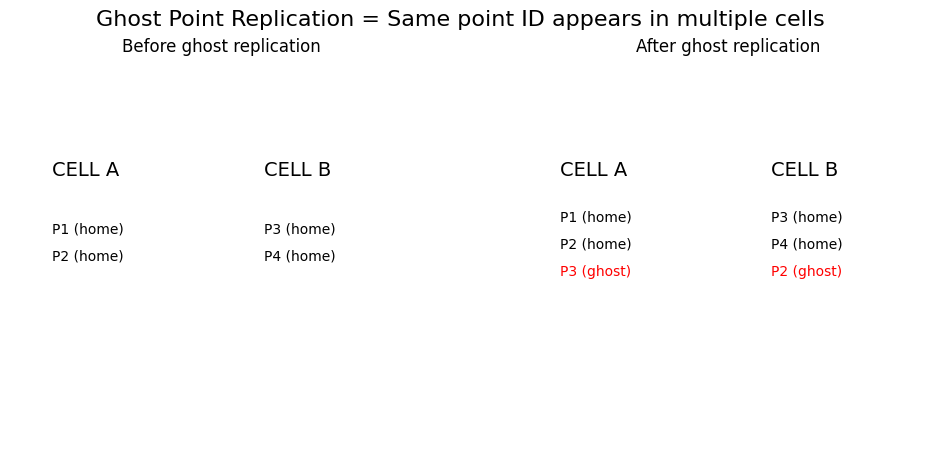

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# ------------------------
# BEFORE ghost replication
# ------------------------
plt.subplot(1,2,1)
plt.title("Before ghost replication")

plt.text(0.1, 0.7, "CELL A", fontsize=14)
plt.text(0.6, 0.7, "CELL B", fontsize=14)

plt.text(0.1, 0.55, "P1 (home)")
plt.text(0.1, 0.48, "P2 (home)")

plt.text(0.6, 0.55, "P3 (home)")
plt.text(0.6, 0.48, "P4 (home)")

plt.axis("off")

# ------------------------
# AFTER ghost replication
# ------------------------
plt.subplot(1,2,2)
plt.title("After ghost replication")

plt.text(0.1, 0.7, "CELL A", fontsize=14)
plt.text(0.6, 0.7, "CELL B", fontsize=14)

# CELL A
plt.text(0.1, 0.58, "P1 (home)")
plt.text(0.1, 0.51, "P2 (home)")
plt.text(0.1, 0.44, "P3 (ghost)", color="red")

# CELL B
plt.text(0.6, 0.58, "P3 (home)")
plt.text(0.6, 0.51, "P4 (home)")
plt.text(0.6, 0.44, "P2 (ghost)", color="red")

plt.axis("off")

plt.suptitle("Ghost Point Replication = Same point ID appears in multiple cells",
             fontsize=16)
plt.show()


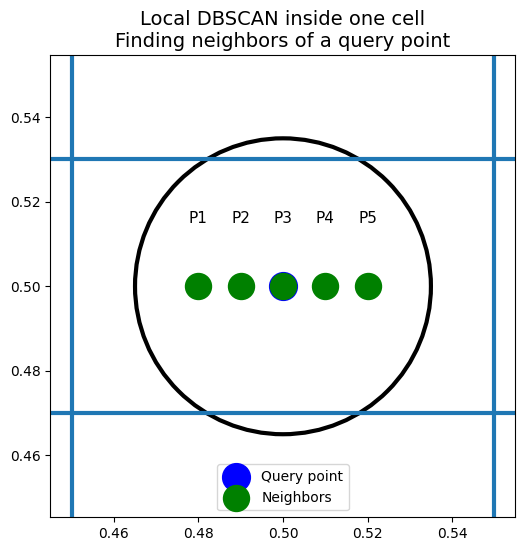

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Points inside ONE CELL after ghost replication
# -------------------------------------------------
# id, x, y
points = np.array([
    [1, 0.48, 0.50],
    [2, 0.49, 0.50],
    [3, 0.50, 0.50],  # query point
    [4, 0.51, 0.50],
    [5, 0.52, 0.50],
])

query = points[2]

plt.figure(figsize=(6,6))

# draw cell
plt.axvline(0.45, linewidth=3)
plt.axvline(0.55, linewidth=3)
plt.axhline(0.47, linewidth=3)
plt.axhline(0.53, linewidth=3)

# draw epsilon neighborhood
circle = plt.Circle(
    (query[1], query[2]),
    0.035,
    fill=False,
    linewidth=3,
    color="black"
)
plt.gca().add_patch(circle)

# plot points
plt.scatter(points[:,1], points[:,2], s=300, color="lightgray")

# highlight query point
plt.scatter(query[1], query[2], s=400, color="blue", label="Query point")

# neighbors
neighbors = points[
    np.abs(points[:,1] - query[1]) <= 0.035
]

plt.scatter(neighbors[:,1], neighbors[:,2],
            s=350, color="green", label="Neighbors")

# annotate
for p in points:
    plt.text(p[1], p[2]+0.015, f"P{int(p[0])}",
             ha="center", fontsize=11)

plt.title(
    "Local DBSCAN inside one cell\n"
    "Finding neighbors of a query point",
    fontsize=14
)

plt.legend()
plt.axis("equal")
plt.show()


# Local DBSCAN

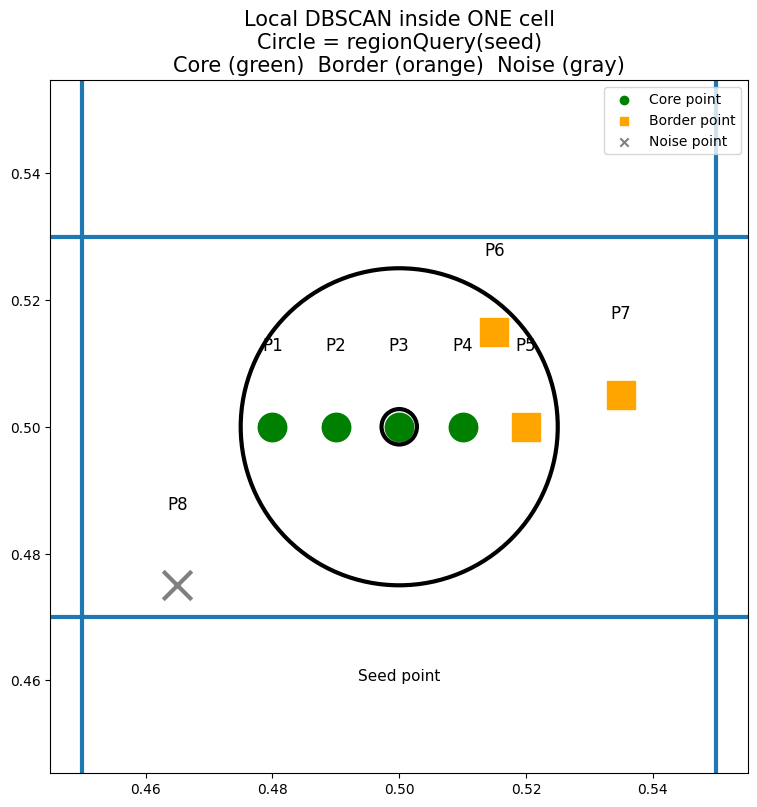

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Points inside ONE cell
# -----------------------------
points = np.array([
    [1, 0.48, 0.50],   # core
    [2, 0.49, 0.50],   # core
    [3, 0.50, 0.50],   # seed (core)
    [4, 0.51, 0.50],   # core
    [5, 0.52, 0.50],   # border
    [6, 0.515, 0.515], # border
    [7, 0.535, 0.505], # border
    [8, 0.465, 0.475], # noise
])

core   = {1,2,3,4}
border = {5,6,7}
noise  = {8}

seed_id = 3
seed = points[points[:,0]==seed_id][0]

eps = 0.025

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9,9))

# draw ONE cell boundary
plt.axvline(0.45, linewidth=3)
plt.axvline(0.55, linewidth=3)
plt.axhline(0.47, linewidth=3)
plt.axhline(0.53, linewidth=3)

# eps region
circle = plt.Circle((seed[1], seed[2]), eps, fill=False, linewidth=3)
plt.gca().add_patch(circle)

# plot points
for p in points:
    pid, x, y = int(p[0]), p[1], p[2]

    if pid in core:
        plt.scatter(x, y, s=420, color="green", marker="o")
    elif pid in border:
        plt.scatter(x, y, s=420, color="orange", marker="s")
    else:
        plt.scatter(x, y, s=420, color="gray", marker="x", linewidths=3)

    # ID label above
    plt.text(x, y+0.012, f"P{pid}", ha='center', fontsize=12)

# highlight seed
plt.scatter(seed[1], seed[2], s=650,
            facecolors='none', edgecolors='black', linewidth=3)
plt.text(seed[1], seed[2]-0.040, "Seed point", ha='center', fontsize=11)

# legend
plt.scatter([], [], color="green", marker='o', label='Core point')
plt.scatter([], [], color="orange", marker='s', label='Border point')
plt.scatter([], [], color="gray", marker='x', label='Noise point')
plt.legend(loc="upper right")

plt.title(
    "Local DBSCAN inside ONE cell\n"
    "Circle = regionQuery(seed)\n"
    "Core (green)  Border (orange)  Noise (gray)",
    fontsize=15
)

plt.axis("equal")
plt.show()


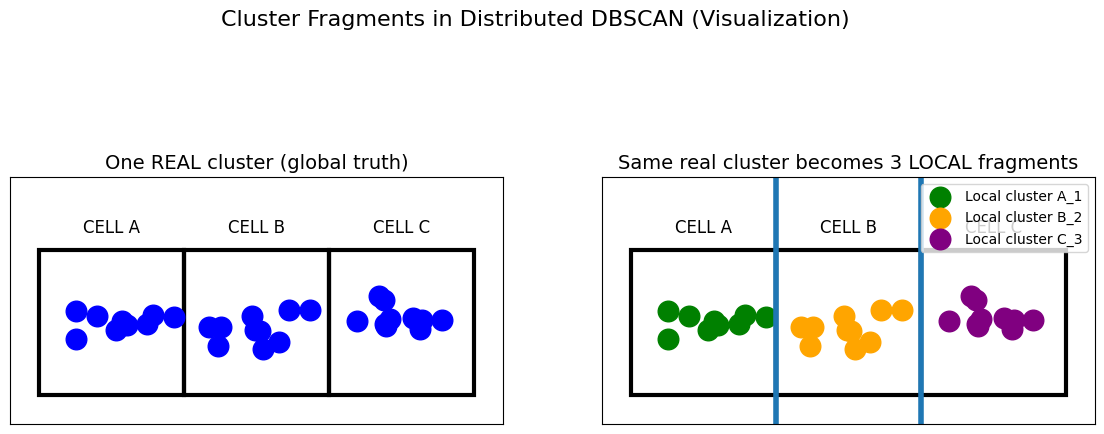

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -------------------------------------------------
# VISUAL: One real cluster split into local fragments by cell partitioning
# (Code-only, no explanation)
# -------------------------------------------------

np.random.seed(7)

# Cell layout: 3 cells horizontally
cell_size = 0.10
x0, y0 = 0.40, 0.45  # leftmost cell bottom-left
cells = [
    ("CELL A", x0 + 0*cell_size, y0),
    ("CELL B", x0 + 1*cell_size, y0),
    ("CELL C", x0 + 2*cell_size, y0),
]

# One "real cluster" stretched across boundaries
# (points intentionally cross cell boundaries)
nA, nB, nC = 10, 10, 10
A = np.column_stack([np.random.uniform(x0+0.02, x0+0.095, nA),
                     np.random.normal(y0+0.05, 0.008, nA)])
B = np.column_stack([np.random.uniform(x0+0.105, x0+0.195, nB),
                     np.random.normal(y0+0.05, 0.008, nB)])
C = np.column_stack([np.random.uniform(x0+0.205, x0+0.285, nC),
                     np.random.normal(y0+0.05, 0.008, nC)])

pts = np.vstack([A, B, C])

# Assign "local cluster fragments" (simulating local DBSCAN IDs per cell)
# Same real cluster -> different local IDs in different cells
frag_labels = np.array(["A_1"]*nA + ["B_2"]*nB + ["C_3"]*nC)

# Colors for fragments (kept simple, consistent)
frag_to_color = {"A_1": "green", "B_2": "orange", "C_3": "purple"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =================================================
# LEFT: Real cluster (global truth)
# =================================================
ax = axes[0]
for name, cx, cy in cells:
    ax.add_patch(patches.Rectangle((cx, cy), cell_size, cell_size,
                                   fill=False, linewidth=3))
    ax.text(cx+cell_size/2, cy+cell_size+0.012, name, ha="center", fontsize=12)

ax.scatter(pts[:,0], pts[:,1], s=220, color="blue")
ax.set_title("One REAL cluster (global truth)", fontsize=14)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(x0-0.02, x0+3*cell_size+0.02)
ax.set_ylim(y0-0.02, y0+cell_size+0.05)
ax.set_xticks([])
ax.set_yticks([])

# =================================================
# RIGHT: Cluster fragments after LOCAL DBSCAN
# =================================================
ax = axes[1]
for name, cx, cy in cells:
    ax.add_patch(patches.Rectangle((cx, cy), cell_size, cell_size,
                                   fill=False, linewidth=3))
    ax.text(cx+cell_size/2, cy+cell_size+0.012, name, ha="center", fontsize=12)

# plot fragments
for frag in ["A_1", "B_2", "C_3"]:
    mask = (frag_labels == frag)
    ax.scatter(pts[mask,0], pts[mask,1],
               s=220, color=frag_to_color[frag], label=f"Local cluster {frag}")

# show "boundaries" more clearly
ax.axvline(x0+cell_size, linewidth=4)
ax.axvline(x0+2*cell_size, linewidth=4)

ax.set_title("Same real cluster becomes 3 LOCAL fragments", fontsize=14)
ax.legend(loc="upper right")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(x0-0.02, x0+3*cell_size+0.02)
ax.set_ylim(y0-0.02, y0+cell_size+0.05)
ax.set_xticks([])
ax.set_yticks([])

plt.suptitle("Cluster Fragments in Distributed DBSCAN (Visualization)", fontsize=16)
plt.show()


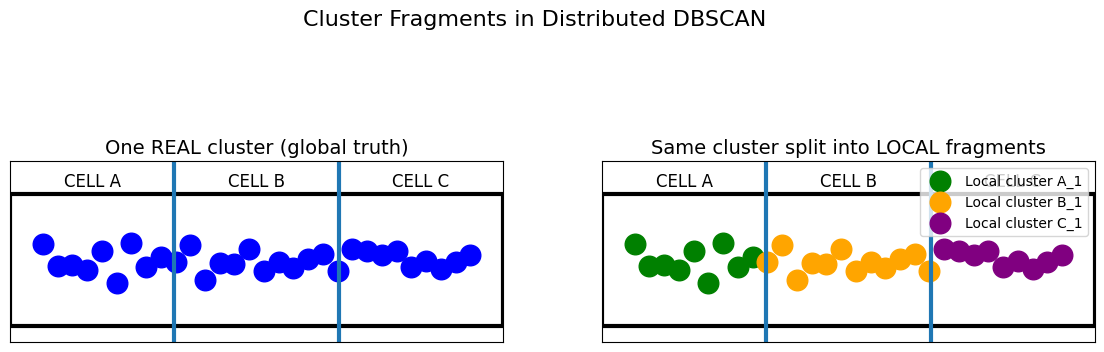

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---------------------------------------------
# One continuous cluster crossing cell boundaries
# ---------------------------------------------
np.random.seed(1)

# continuous horizontal cluster
x = np.linspace(0.42, 0.68, 30)
y = 0.50 + np.random.normal(0, 0.006, 30)
points = np.column_stack((x, y))

# cell boundaries
cell_edges = [0.50, 0.60]

# local cluster IDs assigned per cell
labels = []
for px, py in points:
    if px < 0.50:
        labels.append("A_1")   # Cell A cluster 1
    elif px < 0.60:
        labels.append("B_1")   # Cell B cluster 1
    else:
        labels.append("C_1")   # Cell C cluster 1

labels = np.array(labels)

colors = {
    "A_1": "green",
    "B_1": "orange",
    "C_1": "purple"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ======================================================
# LEFT — REAL CLUSTER (before partition)
# ======================================================
ax = axes[0]

# draw cell boxes
ax.add_patch(patches.Rectangle((0.40, 0.46), 0.30, 0.08,
                               fill=False, linewidth=3))

# draw vertical cuts
for b in cell_edges:
    ax.axvline(b, linewidth=3)

ax.scatter(points[:,0], points[:,1], s=220, color="blue")

ax.text(0.45, 0.545, "CELL A", ha="center", fontsize=12)
ax.text(0.55, 0.545, "CELL B", ha="center", fontsize=12)
ax.text(0.65, 0.545, "CELL C", ha="center", fontsize=12)

ax.set_title("One REAL cluster (global truth)", fontsize=14)
ax.set_xlim(0.40, 0.70)
ax.set_ylim(0.45, 0.56)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

# ======================================================
# RIGHT — LOCAL DBSCAN RESULTS (fragments)
# ======================================================
ax = axes[1]

ax.add_patch(patches.Rectangle((0.40, 0.46), 0.30, 0.08,
                               fill=False, linewidth=3))

for b in cell_edges:
    ax.axvline(b, linewidth=3)

for frag in ["A_1", "B_1", "C_1"]:
    mask = labels == frag
    ax.scatter(points[mask,0], points[mask,1],
               s=220, color=colors[frag],
               label=f"Local cluster {frag}")

ax.text(0.45, 0.545, "CELL A", ha="center", fontsize=12)
ax.text(0.55, 0.545, "CELL B", ha="center", fontsize=12)
ax.text(0.65, 0.545, "CELL C", ha="center", fontsize=12)

ax.set_title("Same cluster split into LOCAL fragments", fontsize=14)
ax.legend(loc="upper right")

ax.set_xlim(0.40, 0.70)
ax.set_ylim(0.45, 0.56)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

plt.suptitle("Cluster Fragments in Distributed DBSCAN", fontsize=16)
plt.show()


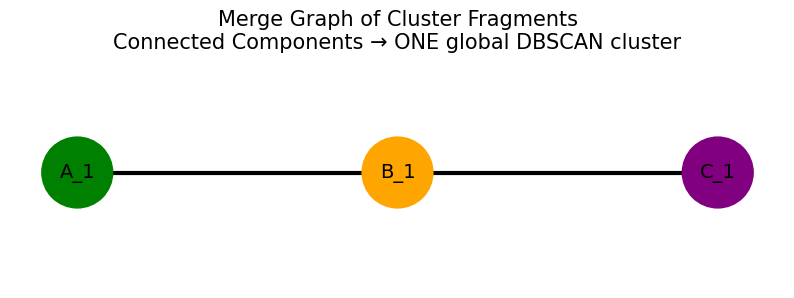

In [103]:
import matplotlib.pyplot as plt
import networkx as nx

# ---------------------------------------
# Create merge graph
# ---------------------------------------
G = nx.Graph()

# Local cluster fragments (vertices)
clusters = ["A_1", "B_1", "C_1"]

# Merge edges discovered from ghost points
edges = [
    ("A_1", "B_1"),
    ("B_1", "C_1")
]

G.add_nodes_from(clusters)
G.add_edges_from(edges)

# ---------------------------------------
# Layout (straight line for clarity)
# ---------------------------------------
pos = {
    "A_1": (0, 0),
    "B_1": (1, 0),
    "C_1": (2, 0)
}

# ---------------------------------------
# Draw graph
# ---------------------------------------
plt.figure(figsize=(10, 3))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=2600,
    node_color=["green", "orange", "purple"]
)

# Edges
nx.draw_networkx_edges(
    G, pos,
    width=3
)

# Labels
nx.draw_networkx_labels(
    G, pos,
    font_size=14,
    font_color="black"
)

# ---------------------------------------
# Titles
# ---------------------------------------
plt.title(
    "Merge Graph of Cluster Fragments\n"
    "Connected Components → ONE global DBSCAN cluster",
    fontsize=15
)

plt.axis("off")
plt.show()


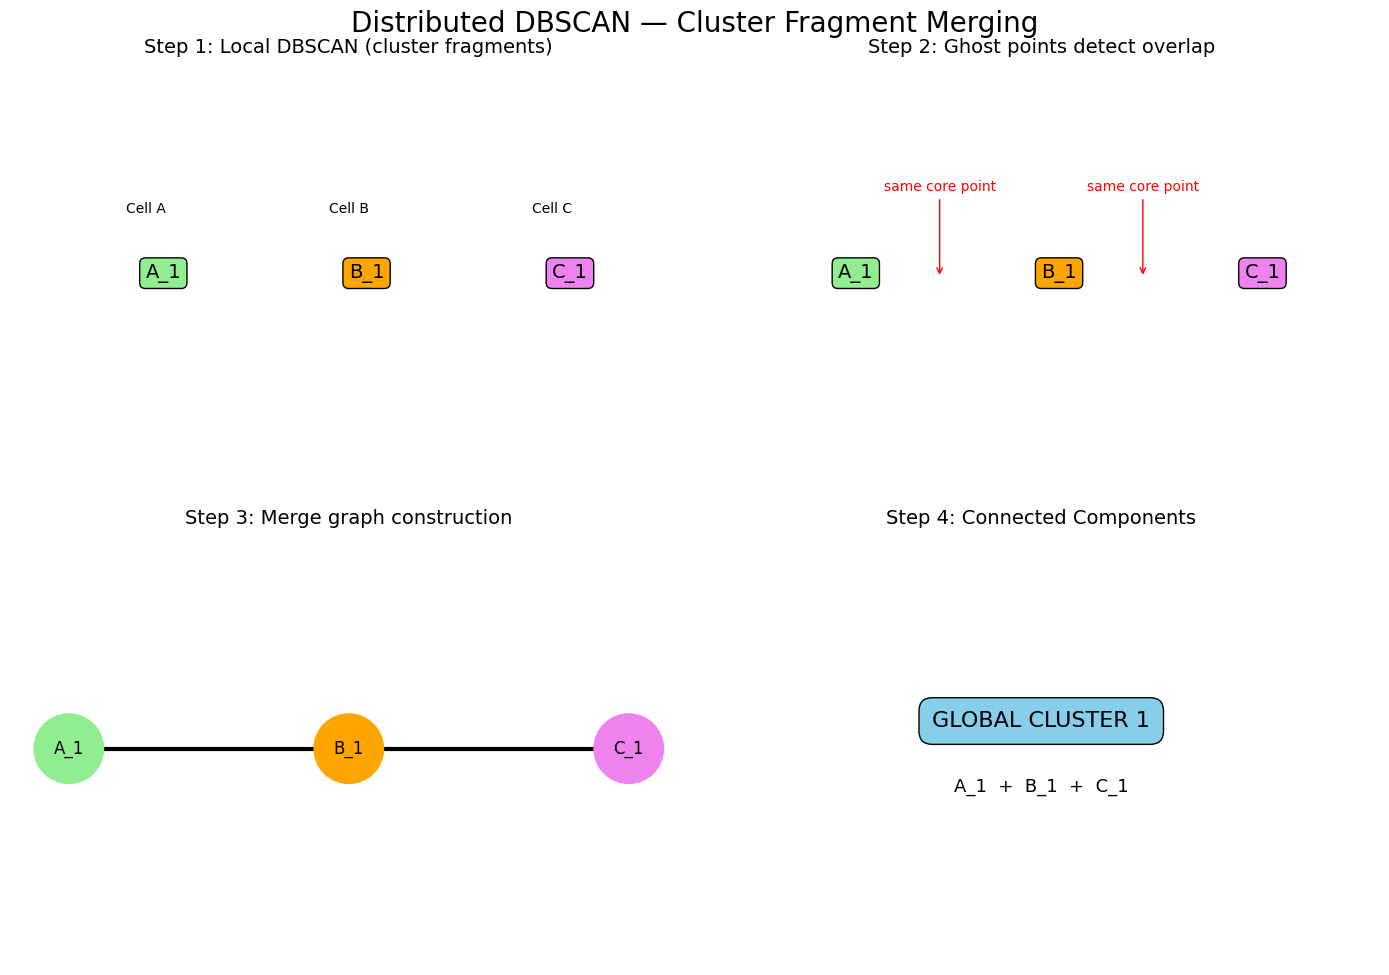

In [105]:
import matplotlib.pyplot as plt
import networkx as nx

fig = plt.figure(figsize=(14,10))

# ======================================================
# TITLE
# ======================================================
fig.suptitle(
    "Distributed DBSCAN — Cluster Fragment Merging",
    fontsize=20,
    y=0.97
)

# ======================================================
# STEP 1 — Local fragments
# ======================================================
ax1 = plt.subplot(2,2,1)
ax1.set_title("Step 1: Local DBSCAN (cluster fragments)", fontsize=14)

ax1.text(0.2, 0.5, "A_1", fontsize=14,
         bbox=dict(boxstyle="round", fc="lightgreen"))
ax1.text(0.5, 0.5, "B_1", fontsize=14,
         bbox=dict(boxstyle="round", fc="orange"))
ax1.text(0.8, 0.5, "C_1", fontsize=14,
         bbox=dict(boxstyle="round", fc="violet"))

ax1.text(0.2, 0.65, "Cell A", ha="center")
ax1.text(0.5, 0.65, "Cell B", ha="center")
ax1.text(0.8, 0.65, "Cell C", ha="center")

ax1.axis("off")

# ======================================================
# STEP 2 — Ghost overlap detection
# ======================================================
ax2 = plt.subplot(2,2,2)
ax2.set_title("Step 2: Ghost points detect overlap", fontsize=14)

ax2.text(0.2, 0.5, "A_1", fontsize=14,
         bbox=dict(boxstyle="round", fc="lightgreen"))
ax2.text(0.5, 0.5, "B_1", fontsize=14,
         bbox=dict(boxstyle="round", fc="orange"))
ax2.text(0.8, 0.5, "C_1", fontsize=14,
         bbox=dict(boxstyle="round", fc="violet"))

ax2.annotate("same core point",
             xy=(0.35,0.5), xytext=(0.35,0.7),
             arrowprops=dict(arrowstyle="->", color="red"),
             color="red", ha="center")

ax2.annotate("same core point",
             xy=(0.65,0.5), xytext=(0.65,0.7),
             arrowprops=dict(arrowstyle="->", color="red"),
             color="red", ha="center")

ax2.axis("off")

# ======================================================
# STEP 3 — Merge graph
# ======================================================
ax3 = plt.subplot(2,2,3)
ax3.set_title("Step 3: Merge graph construction", fontsize=14)

G = nx.Graph()
G.add_edges_from([
    ("A_1","B_1"),
    ("B_1","C_1")
])

pos = {
    "A_1": (0,0),
    "B_1": (1,0),
    "C_1": (2,0)
}

nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    node_color=["lightgreen","orange","violet"],
    width=3,
    ax=ax3
)

ax3.axis("off")

# ======================================================
# STEP 4 — Global cluster
# ======================================================
ax4 = plt.subplot(2,2,4)
ax4.set_title("Step 4: Connected Components", fontsize=14)

ax4.text(
    0.5, 0.55,
    "GLOBAL CLUSTER 1",
    fontsize=16,
    ha="center",
    bbox=dict(boxstyle="round,pad=0.6", fc="skyblue")
)

ax4.text(
    0.5, 0.4,
    "A_1  +  B_1  +  C_1",
    fontsize=13,
    ha="center"
)

ax4.axis("off")

plt.tight_layout()
plt.show()


# Union 

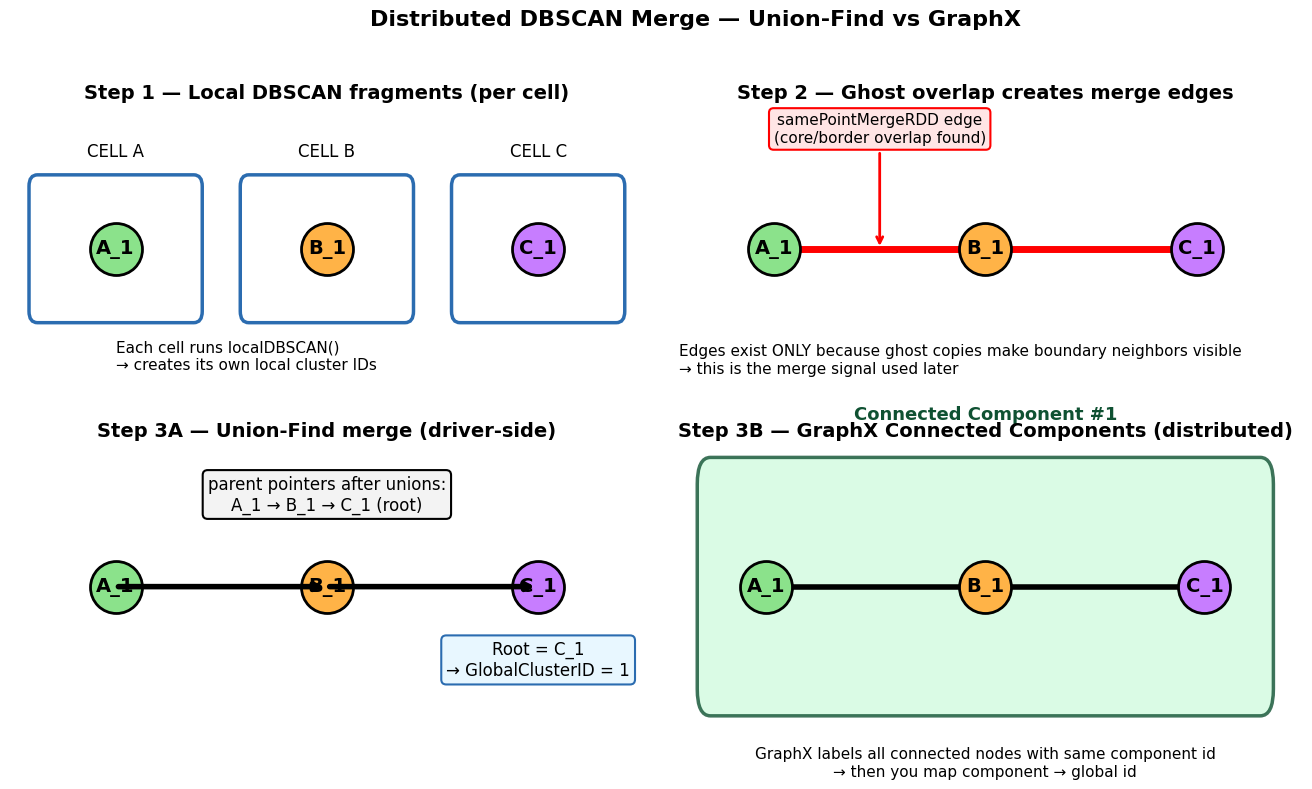

In [117]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx

# ============================================================
# DATA (same concept as your code)
# Local cluster labels = cellId_clusterId
# Edges come from samePointMergeRDD (overlap found by ghost points)
# ============================================================
clusters = ["A_1", "B_1", "C_1"]
merge_edges = [("A_1", "B_1"), ("B_1", "C_1")]   # like (12_1,13_2) etc.

# Consistent positions for drawing
pos_line = {"A_1": (0, 0), "B_1": (2, 0), "C_1": (4, 0)}

# Colors
COL_A = "#8BE28B"
COL_B = "#FFB347"
COL_C = "#C77DFF"
node_color = {"A_1": COL_A, "B_1": COL_B, "C_1": COL_C}

# ============================================================
# Helper: draw a nice node with label
# ============================================================
def draw_node(ax, xy, label, face, size=1400, edge="black", lw=2):
    ax.scatter([xy[0]], [xy[1]], s=size, color=face, edgecolors=edge, linewidths=lw, zorder=3)
    ax.text(xy[0], xy[1], label, ha="center", va="center", fontsize=14, weight="bold", zorder=4)

def draw_edge(ax, a, b, color="black", lw=3):
    xa, ya = pos_line[a]
    xb, yb = pos_line[b]
    ax.plot([xa, xb], [ya, yb], color=color, linewidth=lw, zorder=1)

# ============================================================
# FIGURE: 2 rows × 2 cols
# (1) Local fragments in cells
# (2) Merge edges discovered by ghost overlap
# (3) Union-Find parent pointers
# (4) GraphX connected components result
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ax1, ax2, ax3, ax4 = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

# ---------------------------
# (1) LOCAL FRAGMENTS (cells)
# ---------------------------
ax1.set_title("Step 1 — Local DBSCAN fragments (per cell)", fontsize=14, weight="bold")
ax1.set_xlim(-1, 5)
ax1.set_ylim(-1, 1)
ax1.axis("off")

# draw 3 cell boxes
cell_boxes = [(-0.8, -0.5, 1.6, 1.0, "CELL A"),
              ( 1.2, -0.5, 1.6, 1.0, "CELL B"),
              ( 3.2, -0.5, 1.6, 1.0, "CELL C")]
for x,y,w,h,name in cell_boxes:
    rect = patches.FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                                  linewidth=2.5, edgecolor="#2B6CB0", facecolor="white")
    ax1.add_patch(rect)
    ax1.text(x+w/2, y+h+0.15, name, ha="center", fontsize=12)

# local cluster labels inside each cell
draw_node(ax1, (0.0, 0), "A_1", COL_A)
draw_node(ax1, (2.0, 0), "B_1", COL_B)
draw_node(ax1, (4.0, 0), "C_1", COL_C)

ax1.text(0.0, -0.85, "Each cell runs localDBSCAN()\n→ creates its own local cluster IDs",
         ha="left", fontsize=11)

# -----------------------------------------
# (2) MERGE EDGES FROM GHOST OVERLAP
# -----------------------------------------
ax2.set_title("Step 2 — Ghost overlap creates merge edges", fontsize=14, weight="bold")
ax2.set_xlim(-1, 5)
ax2.set_ylim(-1.2, 1.2)
ax2.axis("off")

# draw the same nodes
for n in clusters:
    draw_node(ax2, pos_line[n], n, node_color[n])

# draw thick red edges = samePointMergeRDD edges
for (u,v) in merge_edges:
    draw_edge(ax2, u, v, color="red", lw=5)

# show a "ghost point evidence" callout
ax2.annotate("samePointMergeRDD edge\n(core/border overlap found)",
             xy=(1.0, 0.0), xytext=(1.0, 0.9),
             ha="center",
             arrowprops=dict(arrowstyle="->", lw=2, color="red"),
             fontsize=11,
             bbox=dict(boxstyle="round", fc="#ffe5e5", ec="red", lw=1.5))

ax2.text(-0.9, -1.05,
         "Edges exist ONLY because ghost copies make boundary neighbors visible\n→ this is the merge signal used later",
         fontsize=11)

# -----------------------------------------
# (3) UNION-FIND (driver) VISUAL
# -----------------------------------------
ax3.set_title("Step 3A — Union-Find merge (driver-side)", fontsize=14, weight="bold")
ax3.set_xlim(-1, 5)
ax3.set_ylim(-1.2, 1.2)
ax3.axis("off")

# show union steps explicitly
# After union(A_1,B_1): parent[A_1]=B_1
# After union(B_1,C_1): parent[B_1]=C_1  => chain A_1→B_1→C_1
for n in clusters:
    draw_node(ax3, pos_line[n], n, node_color[n])

# parent arrows (black)
ax3.annotate("", xy=pos_line["B_1"], xytext=pos_line["A_1"],
             arrowprops=dict(arrowstyle="->", lw=4, color="black"))
ax3.annotate("", xy=pos_line["C_1"], xytext=pos_line["B_1"],
             arrowprops=dict(arrowstyle="->", lw=4, color="black"))

ax3.text(2.0, 0.65,
         "parent pointers after unions:\nA_1 → B_1 → C_1 (root)",
         ha="center", fontsize=12,
         bbox=dict(boxstyle="round", fc="#f3f3f3", ec="black", lw=1.5))

# show final global id assignment
ax3.text(4.0, -0.75, "Root = C_1\n→ GlobalClusterID = 1", ha="center", fontsize=12,
         bbox=dict(boxstyle="round", fc="#e8f7ff", ec="#2B6CB0", lw=1.5))

# -----------------------------------------
# (4) GRAPHX CONNECTED COMPONENTS VISUAL
# -----------------------------------------
ax4.set_title("Step 3B — GraphX Connected Components (distributed)", fontsize=14, weight="bold")

G = nx.Graph()
G.add_nodes_from(clusters)
G.add_edges_from(merge_edges)

# draw with networkx on ax4
ax4.axis("off")
nx.draw_networkx_edges(G, pos_line, ax=ax4, width=4, edge_color="black")

# component shading (all are one component here)
component_box = patches.FancyBboxPatch(
    (-0.6, -0.55), 5.2, 1.1, boxstyle="round,pad=0.03,rounding_size=0.12",
    linewidth=2.5, edgecolor="#0F5132", facecolor="#D1FADF", alpha=0.8, zorder=0
)
ax4.add_patch(component_box)
ax4.text(2.0, 0.75, "Connected Component #1", ha="center", fontsize=13, weight="bold", color="#0F5132")

# draw nodes on top
for n in clusters:
    draw_node(ax4, pos_line[n], n, node_color[n])

ax4.text(2.0, -0.85,
         "GraphX labels all connected nodes with same component id\n→ then you map component → global id",
         ha="center", fontsize=11)

# ---------------------------
# Global title
# ---------------------------
plt.suptitle("Distributed DBSCAN Merge — Union-Find vs GraphX",
             fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
